In [2]:
import pandas as pd
import numpy as np


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)


In [6]:
df = pd.read_csv('../data/diabetic_data.csv')

In [10]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 101766
Columns: 50


In [12]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [14]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [16]:
df.dtypes


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [18]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [20]:
df.describe(include='object')

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


In [26]:
print(df['readmitted'].value_counts())
print(" ")
print("As percentages:")
print(df['readmitted'].value_counts(normalize=True).round(3) * 100)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
 
As percentages:
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64


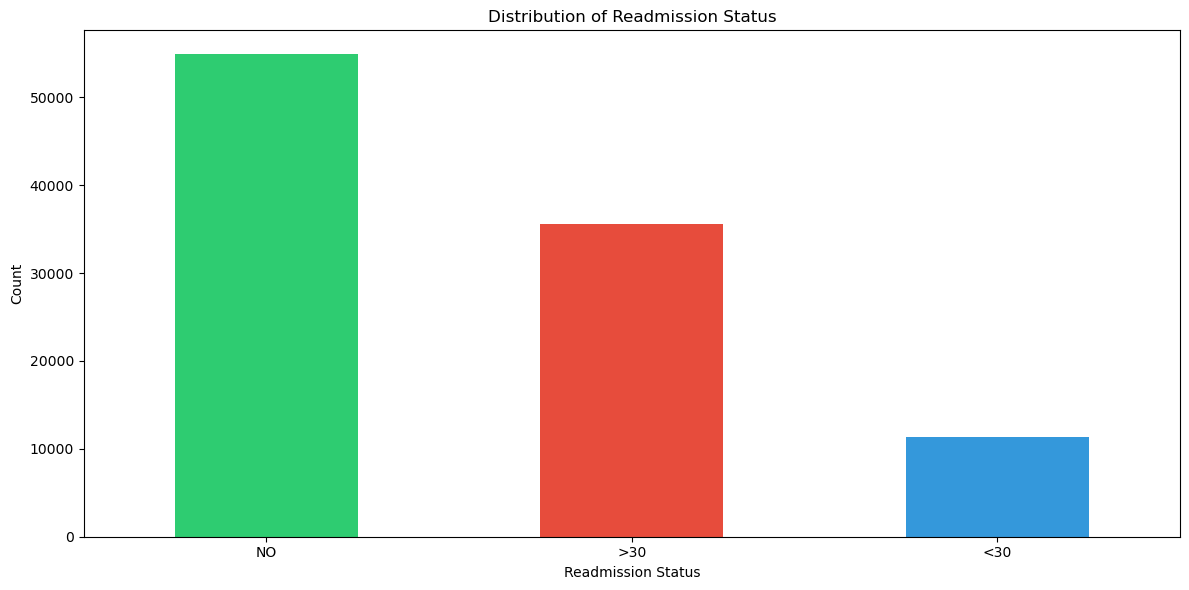

In [28]:
df['readmitted'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c', '#3498db'])
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/target_distribution.png', dpi=150)
plt.show()

In [34]:
df.replace('?', np.nan, inplace=True)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum()/len(df)*100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_report[missing_report['Missing Count'] > 0])

                   Missing Count  Missing %
A1Cresult                  84748      83.28
diag_1                        21       0.02
diag_2                       358       0.35
diag_3                      1423       1.40
max_glu_serum              96420      94.75
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
weight                     98569      96.86


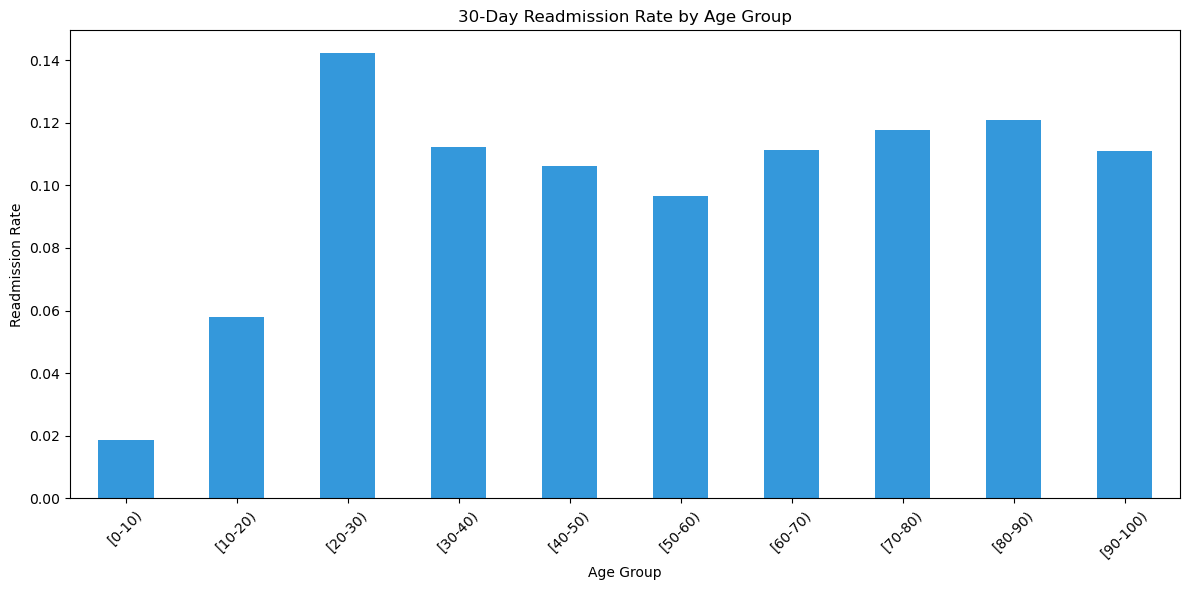

In [36]:
# Create binary target for plotting
df['target'] = (df['readmitted'] == '<30').astype(int)

# Readmission rate by age group
df.groupby('age')['target'].mean().plot(kind='bar', color='#3498db')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/readmission_by_age.png', dpi=150)
plt.show()

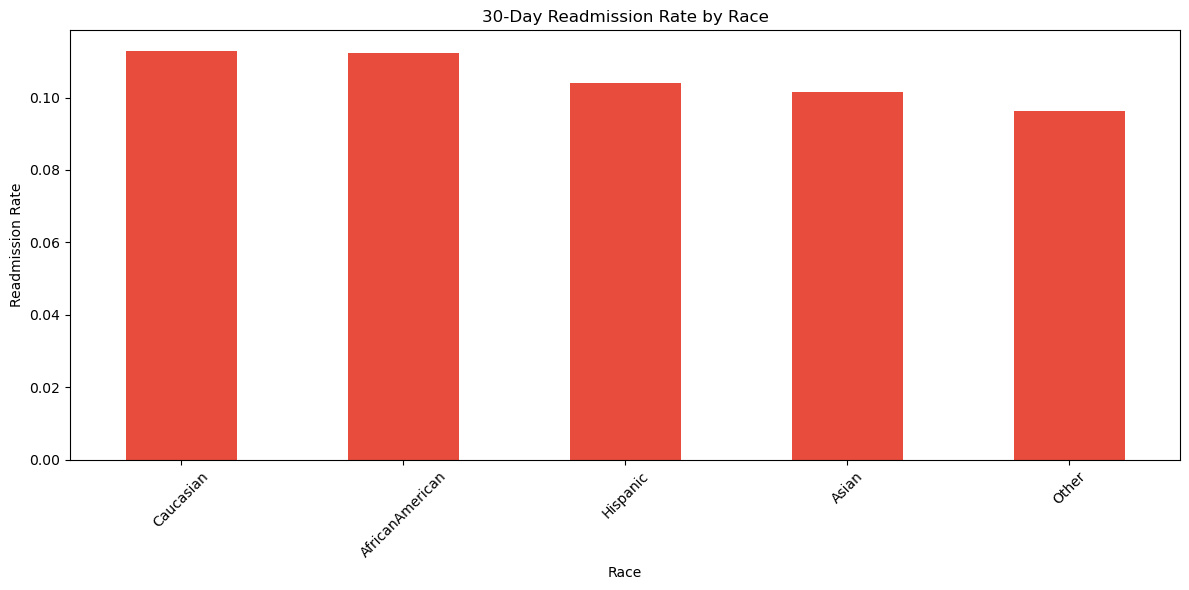

In [38]:
# Readmission rate by race
df.groupby('race')['target'].mean().sort_values(ascending=False).plot(kind='bar', color='#e74c3c')
plt.title('30-Day Readmission Rate by Race')
plt.xlabel('Race')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/readmission_by_race.png', dpi=150)
plt.show()

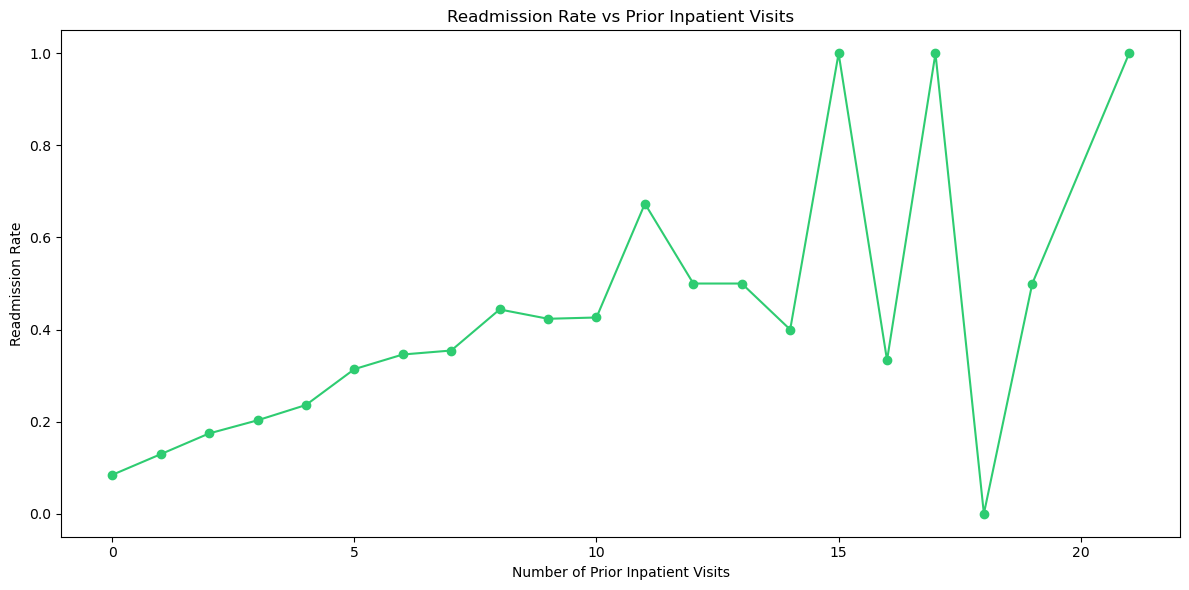

In [40]:
# Readmission rate vs prior inpatient visits
df.groupby('number_inpatient')['target'].mean().plot(kind='line', marker='o', color='#2ecc71')
plt.title('Readmission Rate vs Prior Inpatient Visits')
plt.xlabel('Number of Prior Inpatient Visits')
plt.ylabel('Readmission Rate')
plt.tight_layout()
plt.savefig('../figures/readmission_by_inpatient.png', dpi=150)
plt.show()

In [42]:
print(df['age'].value_counts().sort_index())

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


In [44]:
print(df['number_inpatient'].value_counts().sort_index())

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
Name: count, dtype: int64


In [46]:
readmit_by_inpatient = df.groupby('number_inpatient').agg(
    patient_count=('target', 'count'),
    readmission_rate=('target', 'mean')
).reset_index()

print(readmit_by_inpatient)

    number_inpatient  patient_count  readmission_rate
0                  0          67630          0.084371
1                  1          19521          0.129245
2                  2           7566          0.174333
3                  3           3411          0.202873
4                  4           1622          0.236128
5                  5            812          0.314039
6                  6            480          0.345833
7                  7            268          0.354478
8                  8            151          0.443709
9                  9            111          0.423423
10                10             61          0.426230
11                11             49          0.673469
12                12             34          0.500000
13                13             20          0.500000
14                14             10          0.400000
15                15              9          1.000000
16                16              6          0.333333
17                17        

# Key EDA Findings
1. Target is heavily imbalanced; only ~11% are readmitted within 30 days
2. Age group [20-30) shows highest raw readmission rate, but this appears to be a small sample artifact (n=1,657 vs n=26,068 for [70-80))
3. Readmission rates across racial groups are similar (~0.10), which will be an important baseline for the fairness analysis
4. Prior inpatient visits show a positive trend with readmission for 0-5 visits (reliable sample sizes), but fluctuate wildly beyond 10 visits 
   due to very small patient counts (single digits)
5. Weight is 96.86% missing — will be dropped
6. A1C results and max_glu_serum are 83-95% "missing," but this represents "Test not ordered" rather than lost data—clinically meaningful signal

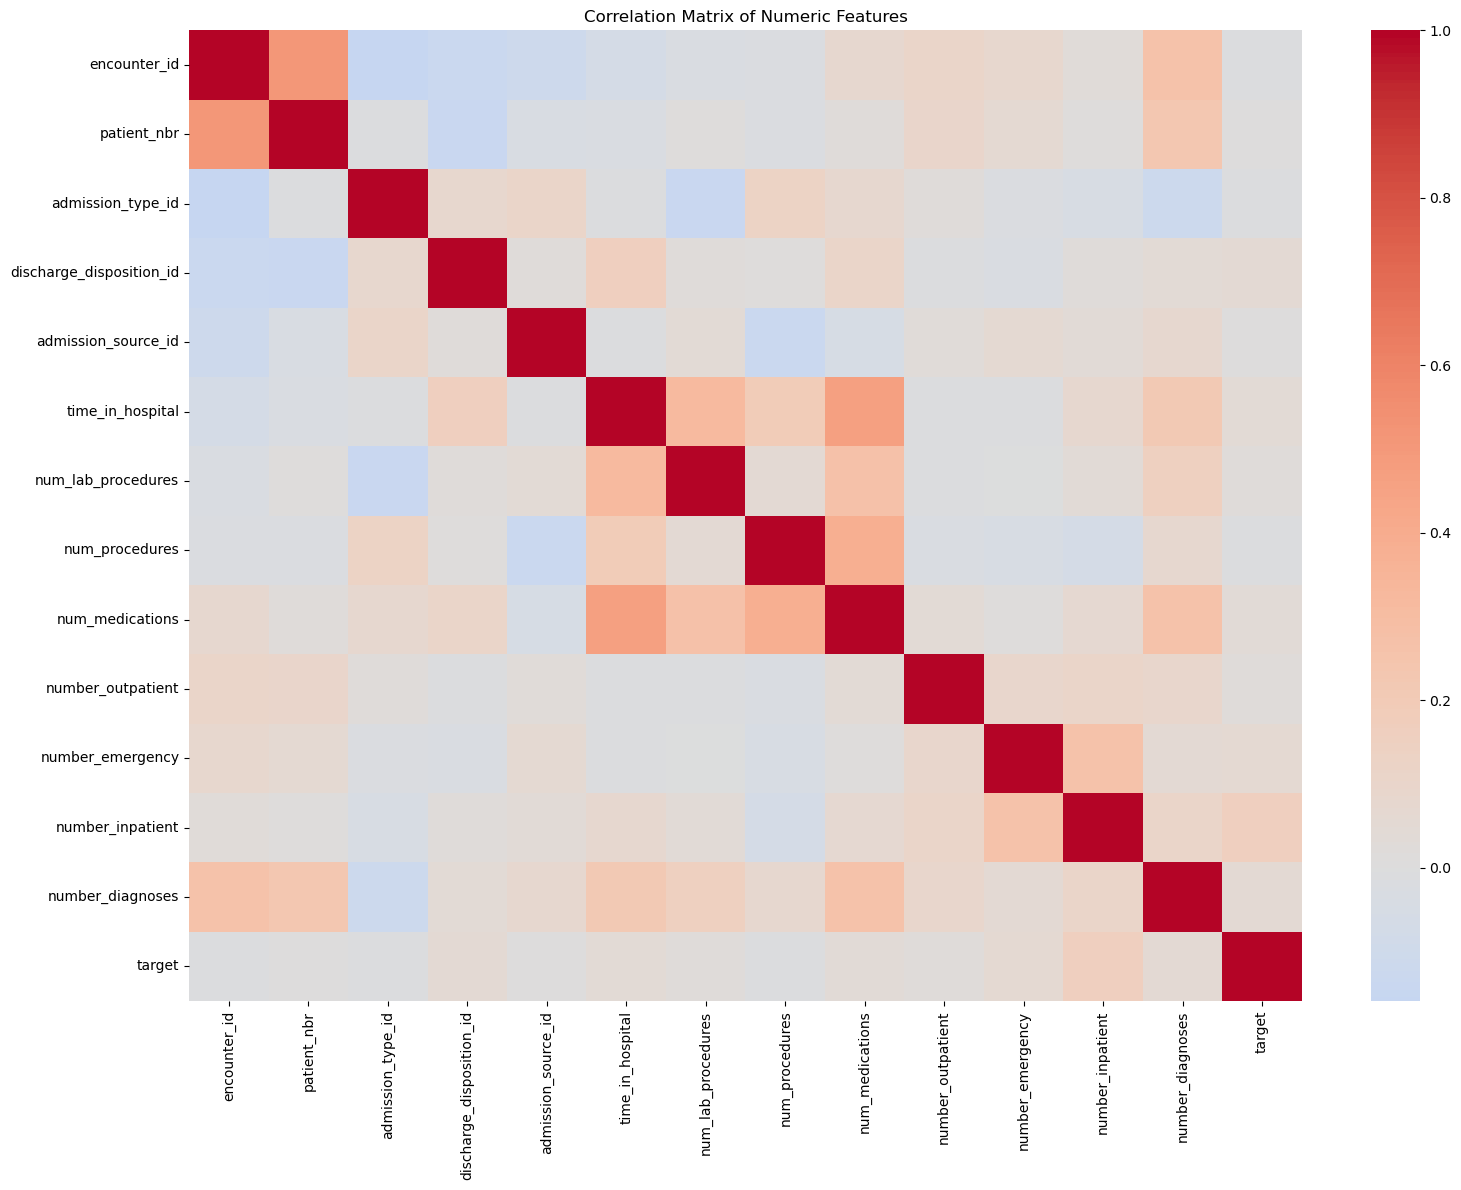

In [48]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=150)
plt.show()

# Correlation Findings
1. No single feature strongly correlates with readmission—prediction 
   will require combining multiple features (justifies ensemble models like XGBoost over simple approaches)
2. time_in_hospital, num_lab_procedures, num_procedures, and 
   num_medications form a correlated cluster representing case complexity
3. number_inpatient shows the strongest individual correlation with the target; prior hospitalization history is the best single predictor
4. Prior visit features (outpatient, emergency, inpatient) correlate with each other, supporting the creation of a combined total_visits feature